In [6]:
from pathlib import Path
import json
import sys

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
BACKEND_DIR = PROJECT_ROOT / 'backend'
if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

from audio_analysis import HOP_LENGTH, analyze_audio_structure

In [7]:
from difflib import SequenceMatcher
import re

PART_RANGE = (6, 10)
MIN_SECTION_DURATION = 8.0
MAX_SECTIONS = 10
VALIDATION_TOLERANCE_SECONDS = 2.5


def moving_average(values: np.ndarray, width: int) -> np.ndarray:
    if width <= 1:
        return values
    kernel = np.ones(width, dtype=float) / width
    return np.convolve(values, kernel, mode='same')


def local_peak_indices(values: np.ndarray, min_distance: int = 4, min_percentile: float = 75.0) -> np.ndarray:
    if values.size < 3:
        return np.array([], dtype=int)

    threshold = np.percentile(values, min_percentile)
    peaks: list[int] = []

    for idx in range(1, len(values) - 1):
        if values[idx] < threshold:
            continue
        if values[idx] >= values[idx - 1] and values[idx] > values[idx + 1]:
            if peaks and idx - peaks[-1] < min_distance:
                if values[idx] > values[peaks[-1]]:
                    peaks[-1] = idx
                continue
            peaks.append(idx)

    return np.array(peaks, dtype=int)


def snap_to_nearest(value: float, anchors: np.ndarray, max_distance: float = 0.35) -> float:
    if anchors.size == 0:
        return round(float(value), 3)

    idx = int(np.argmin(np.abs(anchors - value)))
    snapped = float(anchors[idx])
    if abs(snapped - value) <= max_distance:
        return round(snapped, 3)
    return round(float(value), 3)


def parse_time_seconds(token: str) -> float:
    normalized = token.strip().lower().replace('s', '')
    if ':' in normalized:
        parts = [float(part) for part in normalized.split(':')]
        if len(parts) == 2:
            return parts[0] * 60.0 + parts[1]
        if len(parts) == 3:
            return parts[0] * 3600.0 + parts[1] * 60.0 + parts[2]
        raise ValueError(f'Unsupported time token: {token}')
    return float(normalized)


def find_validation_data_path(case_dir: Path) -> Path | None:
    for name in ('validation_data.txt', 'validaion_data.txt', 'metadata.txt'):
        candidate = case_dir / name
        if candidate.exists():
            return candidate
    return None


def load_validation_structure(validation_path: Path | None) -> list[dict[str, object]]:
    if validation_path is None or not validation_path.exists():
        return []

    explicit_range_pattern = re.compile(r'(\d+(?::\d+(?:\.\d+)?)?)\s*-\s*(\d+(?::\d+(?:\.\d+)?)?)')
    compact_clock_pattern = re.compile(r'\d{1,2}:\d{2}(?:\.\d+)?')
    numeric_pattern = re.compile(r'\d+(?:\.\d+)?')

    rows: list[dict[str, object]] = []
    for raw_line in validation_path.read_text(encoding='utf-8').splitlines():
        line = raw_line.strip()
        if not line:
            continue

        lowered = line.lower()
        if lowered.startswith('tempo') or lowered.startswith('structure'):
            continue

        label = ''
        start_token = ''
        end_token = ''

        explicit_match = explicit_range_pattern.search(line)
        if explicit_match:
            label = line[:explicit_match.start()].rstrip(': ').strip()
            start_token, end_token = explicit_match.group(1), explicit_match.group(2)
        else:
            compact_tokens = compact_clock_pattern.findall(line)
            if len(compact_tokens) >= 2:
                start_token, end_token = compact_tokens[0], compact_tokens[1]
                first_idx = line.find(start_token)
                label = line[:first_idx].rstrip(': ').strip()
            else:
                numeric_tokens = numeric_pattern.findall(line)
                if len(numeric_tokens) < 2:
                    continue
                start_token, end_token = numeric_tokens[0], numeric_tokens[1]
                first_idx = line.find(start_token)
                label = line[:first_idx].rstrip(': ').strip()

        try:
            start_sec = parse_time_seconds(start_token)
            end_sec = parse_time_seconds(end_token)
        except ValueError:
            continue

        if end_sec <= start_sec:
            continue

        rows.append(
            {
                'section': label if label else f'section_{len(rows) + 1}',
                'start': round(start_sec, 3),
                'end': round(end_sec, 3),
                'duration': round(end_sec - start_sec, 3),
            }
        )

    return rows


def resolve_case_assets(preferred_case: str = 'clip') -> tuple[Path, Path | None, Path | None, str]:
    root = PROJECT_ROOT / 'test_data'

    search_dirs: list[Path] = []
    preferred_dir = root / preferred_case
    if preferred_dir.exists():
        search_dirs.append(preferred_dir)

    for name in ('clip', 'goral'):
        case_dir = root / name
        if case_dir.exists() and case_dir not in search_dirs:
            search_dirs.append(case_dir)

    if root.exists() and root not in search_dirs:
        search_dirs.append(root)

    audio_candidates = [
        f'{preferred_case}.mp3',
        'clip.mp3',
        'goral.mp3',
        'guitar skolim ale nie.mp3',
    ]

    for directory in search_dirs:
        for audio_name in audio_candidates:
            audio_path = directory / audio_name
            if not audio_path.exists():
                continue

            alignment_path = directory / 'last_align_response.json'
            if not alignment_path.exists():
                alignment_path = None

            validation_path = find_validation_data_path(directory)
            if validation_path is None and directory != root:
                validation_path = find_validation_data_path(root)

            return audio_path, alignment_path, validation_path, directory.name

    raise FileNotFoundError('No supported audio file found under test_data.')


def validate_boundary_alignment(
    section_boundaries: np.ndarray,
    validation_sections: list[dict[str, object]],
    tolerance_seconds: float = VALIDATION_TOLERANCE_SECONDS,
) -> pd.DataFrame:
    if not validation_sections:
        return pd.DataFrame()

    detected_boundaries = np.array(section_boundaries, dtype=float)
    if detected_boundaries.size == 0:
        return pd.DataFrame()

    expected_boundaries = sorted(
        {
            round(float(section['start']), 3)
            for section in validation_sections
        }
        | {
            round(float(section['end']), 3)
            for section in validation_sections
        }
    )

    rows: list[dict[str, object]] = []
    for expected in expected_boundaries:
        nearest_idx = int(np.argmin(np.abs(detected_boundaries - expected)))
        detected = float(detected_boundaries[nearest_idx])
        delta = round(abs(detected - expected), 3)
        rows.append(
            {
                'expected_boundary_s': round(expected, 3),
                'nearest_detected_s': round(detected, 3),
                'abs_error_s': delta,
                'within_tolerance': delta <= tolerance_seconds,
            }
        )

    return pd.DataFrame(rows)


def validate_section_alignment(
    section_boundaries: np.ndarray,
    validation_sections: list[dict[str, object]],
    tolerance_seconds: float = VALIDATION_TOLERANCE_SECONDS,
) -> pd.DataFrame:
    if not validation_sections:
        return pd.DataFrame()

    detected = np.array(section_boundaries, dtype=float)
    detected_segments_df = pd.DataFrame(
        {
            'detected_segment': list(range(1, len(detected))),
            'start': detected[:-1],
            'end': detected[1:],
        }
    )

    rows: list[dict[str, object]] = []
    for index, validation_row in enumerate(validation_sections):
        m_start = float(validation_row['start'])
        m_end = float(validation_row['end'])
        m_duration = max(0.001, m_end - m_start)

        segment_starts = detected_segments_df['start'].to_numpy()
        segment_ends = detected_segments_df['end'].to_numpy()

        overlaps = np.maximum(
            0.0,
            np.minimum(segment_ends, m_end) - np.maximum(segment_starts, m_start),
        )

        overlap_threshold = max(0.2, 0.015 * m_duration)
        overlapping_idx = np.flatnonzero(overlaps >= overlap_threshold)

        if overlapping_idx.size == 0 and overlaps.size:
            overlapping_idx = np.array([int(np.argmax(overlaps))], dtype=int)
        if overlapping_idx.size == 0:
            continue

        first_idx = int(overlapping_idx[0])
        last_idx = int(overlapping_idx[-1])

        d_start = float(segment_starts[first_idx])
        d_end = float(segment_ends[last_idx])
        overlap_total = float(np.sum(overlaps[overlapping_idx]))

        start_delta = round(d_start - m_start, 3)
        end_delta = round(d_end - m_end, 3)
        coverage = round(min(1.0, overlap_total / m_duration), 3)

        has_nested_subsections = any(
            other_idx != index
            and float(other['start']) >= m_start - 1e-9
            and float(other['end']) <= m_end + 1e-9
            and (float(other['end']) - float(other['start'])) < m_duration - 1e-6
            for other_idx, other in enumerate(validation_sections)
        )

        rows.append(
            {
                'validation_section': str(validation_row['section']),
                'validation_start_s': round(m_start, 3),
                'validation_end_s': round(m_end, 3),
                'matched_detected_segment': int(detected_segments_df.iloc[first_idx]['detected_segment']),
                'detected_start_s': round(d_start, 3),
                'detected_end_s': round(d_end, 3),
                'start_delta_s': start_delta,
                'end_delta_s': end_delta,
                'coverage_ratio': coverage,
                'spans_multiple_segments': int(overlapping_idx.size > 1),
                'contains_nested_sections': int(has_nested_subsections),
                'valid': (
                    abs(start_delta) <= tolerance_seconds
                    and abs(end_delta) <= tolerance_seconds
                    and coverage >= 0.65
                ),
            }
        )

    return pd.DataFrame(rows)


def choose_target_parts(
    part_range: tuple[int, int],
    duration: float,
    bpm: float,
    cue_count: int,
    section_count: int,
    peak_count: int,
    max_supported_parts: int,
) -> int:
    low, high = part_range

    density = 0.0
    density += min(1.0, max(0.0, (bpm - 80.0) / 80.0)) * 0.35
    density += min(1.0, cue_count / max(1.0, duration / 5.0)) * 0.30
    density += min(1.0, section_count / max(1.0, duration / 10.0)) * 0.20
    density += min(1.0, peak_count / max(1.0, duration / 3.0)) * 0.15

    target = int(round(low + (high - low) * min(1.0, density)))
    return max(low, min(target, max_supported_parts))


def build_cut_plan(
    analysis: dict[str, object],
    cues: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    part_range: tuple[int, int],
) -> tuple[list[float], list[dict[str, object]], list[dict[str, object]], np.ndarray]:
    duration = float(analysis['duration'])
    bpm = float(analysis['bpm'])
    beat_grid = np.array(analysis['beatGrid'], dtype=float)
    section_boundaries = np.array(analysis['sectionBoundaries'], dtype=float)

    peak_idx = local_peak_indices(rms_values, min_distance=5, min_percentile=70.0)
    energy_peaks = np.array(
        [snap_to_nearest(float(rms_times[idx]), beat_grid, 0.4) for idx in peak_idx],
        dtype=float,
    )

    if rms_values.max() > rms_values.min():
        rms_norm = (rms_values - rms_values.min()) / (rms_values.max() - rms_values.min())
    else:
        rms_norm = np.zeros_like(rms_values)

    candidates: dict[float, dict[str, object]] = {}

    def add_candidate(time_sec: float, base_score: float, reason: str) -> None:
        time_sec = float(np.clip(time_sec, 0.0, duration))
        if time_sec <= 0.5 or time_sec >= duration - 0.5:
            return

        snapped = snap_to_nearest(time_sec, beat_grid, 0.35)
        item = candidates.setdefault(
            snapped,
            {
                'time': snapped,
                'score': 0.0,
                'reasons': [],
            },
        )
        item['score'] = max(float(item['score']), base_score)
        if reason not in item['reasons']:
            item['reasons'].append(reason)

    for boundary in section_boundaries[1:-1]:
        add_candidate(float(boundary), 1.0, 'section-change')

    for cue in cues:
        cue_start = float(cue.get('start', 0.0))
        cue_end = cue_start + max(0.2, float(cue.get('duration', 0.0)))
        add_candidate(cue_start, 0.72, 'lyric-start')
        add_candidate(cue_end, 0.82, 'lyric-end')

    for idx in range(len(cues) - 1):
        prev_end = float(cues[idx].get('start', 0.0)) + max(0.2, float(cues[idx].get('duration', 0.0)))
        next_start = float(cues[idx + 1].get('start', 0.0))
        pause = next_start - prev_end
        if pause >= 0.35:
            add_candidate((prev_end + next_start) / 2.0, 0.94, f'lyric-pause {pause:.2f}s')

    for idx in peak_idx:
        score = 0.55 + 0.35 * float(rms_norm[idx])
        add_candidate(float(rms_times[idx]), score, 'energy-peak')

    ranked = sorted(
        candidates.values(),
        key=lambda item: (-float(item['score']), float(item['time'])),
    )

    max_supported_parts = max(2, int(duration // 1.8))
    target_parts = choose_target_parts(
        part_range=part_range,
        duration=duration,
        bpm=bpm,
        cue_count=len(cues),
        section_count=max(0, len(section_boundaries) - 1),
        peak_count=len(peak_idx),
        max_supported_parts=max_supported_parts,
    )

    ideal_gap = duration / target_parts
    min_gap = max(1.6, ideal_gap * 0.55)
    max_gap = ideal_gap * 1.70

    selected = [0.0, duration]
    selected_meta: dict[float, dict[str, object]] = {}

    def gap_ok(time_sec: float) -> bool:
        boundaries = sorted(selected + [time_sec])
        gaps = np.diff(boundaries)
        return bool(np.all(gaps >= min_gap - 1e-9))

    for item in ranked:
        if len(selected) >= target_parts + 1:
            break
        time_sec = float(item['time'])
        if gap_ok(time_sec):
            selected.append(time_sec)
            selected_meta[time_sec] = item

    while len(selected) < target_parts + 1:
        boundaries = sorted(selected)
        gaps = [(boundaries[i], boundaries[i + 1]) for i in range(len(boundaries) - 1)]
        start, end = max(gaps, key=lambda pair: pair[1] - pair[0])
        midpoint = snap_to_nearest((start + end) / 2.0, beat_grid, 0.5)
        if midpoint <= start + min_gap / 2.0 or midpoint >= end - min_gap / 2.0:
            break
        if midpoint not in selected:
            selected.append(midpoint)
            selected_meta[midpoint] = {
                'time': midpoint,
                'score': 0.40,
                'reasons': ['spacing-fill'],
            }

    selected = sorted(set(round(float(time_sec), 3) for time_sec in selected))

    changed = True
    while changed:
        changed = False
        for start, end in zip(selected[:-1], selected[1:]):
            if end - start <= max_gap:
                continue

            interval_candidates = [
                item
                for item in ranked
                if start + min_gap / 2.0 < float(item['time']) < end - min_gap / 2.0
            ]

            if interval_candidates:
                choice = float(interval_candidates[0]['time'])
            else:
                choice = snap_to_nearest((start + end) / 2.0, beat_grid, 0.5)

            if choice not in selected and start + min_gap / 2.0 < choice < end - min_gap / 2.0:
                selected.append(choice)
                if choice not in selected_meta:
                    selected_meta[choice] = {
                        'time': choice,
                        'score': 0.45,
                        'reasons': ['gap-split'],
                    }
                selected = sorted(selected)
                changed = True
                break

    segments: list[dict[str, object]] = []
    for segment_number, (start, end) in enumerate(zip(selected[:-1], selected[1:]), start=1):
        reason_tokens: list[str] = []
        for boundary in (start, end):
            meta = selected_meta.get(boundary)
            if meta:
                reason_tokens.extend(str(reason) for reason in meta['reasons'])

        cue_snippets: list[str] = []
        for cue in cues:
            cue_start = float(cue.get('start', 0.0))
            cue_end = cue_start + max(0.2, float(cue.get('duration', 0.0)))
            overlap = max(0.0, min(end, cue_end) - max(start, cue_start))
            if overlap >= 0.35:
                cue_snippets.append(str(cue.get('text', '')))

        label = ' | '.join(cue_snippets[:2]).strip()
        if len(label) > 80:
            label = label[:77] + '...'

        segments.append(
            {
                'segment': segment_number,
                'start': round(start, 3),
                'end': round(end, 3),
                'duration': round(end - start, 3),
                'drivers': ', '.join(dict.fromkeys(reason_tokens)) if reason_tokens else 'start/end',
                'lyric_excerpt': label,
            }
        )

    return selected, ranked, segments, energy_peaks


def normalize_lyric_text(text: str) -> str:
    cleaned = ''.join(char.lower() if char.isalnum() or char.isspace() else ' ' for char in str(text))
    return ' '.join(cleaned.split())


def build_cue_records(cues: list[dict[str, object]]) -> tuple[list[dict[str, object]], float]:
    raw_durations = [max(0.0, float(cue.get('duration', 0.0))) for cue in cues]
    positive_durations = [value for value in raw_durations if value > 0.0]
    duration_cap = max(6.0, float(np.median(positive_durations)) * 3.5 if positive_durations else 6.0)

    records: list[dict[str, object]] = []
    for cue in cues:
        start = float(cue.get('start', 0.0))
        raw_duration = max(0.2, float(cue.get('duration', 0.0)))
        base_end = start + raw_duration
        words = cue.get('words', []) if isinstance(cue.get('words', []), list) else []

        local_word_ends: list[float] = []
        low_conf_words = 0
        total_words = 0
        for word in words:
            total_words += 1
            confidence = float(word.get('confidence', 1.0))
            if confidence < 0.55:
                low_conf_words += 1

            try:
                word_start = float(word.get('startMs')) / 1000.0
                word_end = float(word.get('endMs')) / 1000.0
            except (TypeError, ValueError):
                continue

            if word_end < word_start:
                continue

            if start - 0.4 <= word_start <= start + duration_cap + 1.0:
                local_word_ends.append(word_end)

        inferred_end = max(local_word_ends) if local_word_ends else base_end
        cue_end = max(start + 0.2, inferred_end)
        cue_end = min(cue_end, start + duration_cap)
        if raw_duration <= duration_cap:
            cue_end = min(cue_end, base_end + 0.15)
        if cue_end <= start:
            cue_end = start + 0.2

        confidence_ratio = 1.0 - (low_conf_words / max(1, total_words))

        records.append(
            {
                'start': round(start, 3),
                'end': round(cue_end, 3),
                'duration': round(cue_end - start, 3),
                'text': str(cue.get('text', '')).strip(),
                'normalized_text': normalize_lyric_text(str(cue.get('text', ''))),
                'confidence_ratio': round(float(np.clip(confidence_ratio, 0.0, 1.0)), 3),
                'is_truncated': raw_duration > duration_cap + 1e-9,
            }
        )

    records = sorted(records, key=lambda item: float(item['start']))
    return records, round(duration_cap, 3)


def compute_segment_features(
    segments: list[dict[str, object]],
    cue_records: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    onset_times: np.ndarray,
    onset_values: np.ndarray,
    energy_peaks: np.ndarray,
    duration: float,
) -> list[dict[str, object]]:
    features: list[dict[str, object]] = []

    for segment in segments:
        start = float(segment['start'])
        end = float(segment['end'])
        segment_duration = max(0.001, end - start)

        overlaps: list[float] = []
        overlap_texts: list[str] = []
        overlap_confidences: list[float] = []

        for cue in cue_records:
            cue_start = float(cue['start'])
            cue_end = float(cue['end'])
            overlap = max(0.0, min(end, cue_end) - max(start, cue_start))
            if overlap >= 0.05:
                overlaps.append(overlap)
                overlap_texts.append(str(cue['normalized_text']))
                overlap_confidences.append(float(cue['confidence_ratio']))

        lyric_coverage = sum(overlaps)
        lyric_coverage_ratio = lyric_coverage / segment_duration
        cue_density = len(overlaps) / segment_duration
        mean_cue_confidence = float(np.mean(overlap_confidences)) if overlap_confidences else 0.0

        unique_texts = [text for text in dict.fromkeys(overlap_texts) if text]
        lyric_signature = ' | '.join(unique_texts[:3])

        rms_mask = (rms_times >= start) & (rms_times < end)
        if np.any(rms_mask):
            seg_rms = rms_values[rms_mask]
        else:
            seg_rms = np.array([0.0])

        onset_mask = (onset_times >= start) & (onset_times < end)
        if np.any(onset_mask):
            seg_onset = onset_values[onset_mask]
        else:
            seg_onset = np.array([0.0])

        peak_count = int(np.sum((energy_peaks >= start) & (energy_peaks < end)))
        peak_density = peak_count / segment_duration
        relative_center = ((start + end) / 2.0) / max(1.0, duration)

        energy_trend = float(seg_rms[-1] - seg_rms[0]) if seg_rms.size > 1 else 0.0

        features.append(
            {
                'segment': int(segment['segment']),
                'start': start,
                'end': end,
                'duration': segment_duration,
                'lyric_coverage_ratio': lyric_coverage_ratio,
                'cue_density': cue_density,
                'mean_cue_confidence': mean_cue_confidence,
                'lyric_signature': lyric_signature,
                'energy_mean': float(np.mean(seg_rms)),
                'energy_std': float(np.std(seg_rms)),
                'energy_trend': energy_trend,
                'onset_mean': float(np.mean(seg_onset)),
                'peak_density': peak_density,
                'relative_center': relative_center,
            }
        )

    for idx, feature in enumerate(features):
        max_similarity = 0.0
        max_non_adj_similarity = 0.0

        for other_idx, other in enumerate(features):
            if idx == other_idx:
                continue

            if not feature['lyric_signature'] or not other['lyric_signature']:
                continue

            ratio = float(SequenceMatcher(None, feature['lyric_signature'], other['lyric_signature']).ratio())
            max_similarity = max(max_similarity, ratio)
            if abs(other_idx - idx) > 1:
                max_non_adj_similarity = max(max_non_adj_similarity, ratio)

        feature['repeat_similarity'] = max_similarity
        feature['repeat_non_adj_similarity'] = max_non_adj_similarity

    return features


def label_structure_segments(
    segments: list[dict[str, object]],
    cue_records: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    onset_times: np.ndarray,
    onset_values: np.ndarray,
    energy_peaks: np.ndarray,
    duration: float,
) -> tuple[list[dict[str, object]], pd.DataFrame, pd.DataFrame]:
    features = compute_segment_features(
        segments=segments,
        cue_records=cue_records,
        rms_times=rms_times,
        rms_values=rms_values,
        onset_times=onset_times,
        onset_values=onset_values,
        energy_peaks=energy_peaks,
        duration=duration,
    )

    if not features:
        empty_df = pd.DataFrame()
        return segments, empty_df, empty_df

    energy_means = np.array([feature['energy_mean'] for feature in features], dtype=float)
    onset_means = np.array([feature['onset_mean'] for feature in features], dtype=float)

    energy_q40 = float(np.quantile(energy_means, 0.40))
    energy_q60 = float(np.quantile(energy_means, 0.60))
    onset_q60 = float(np.quantile(onset_means, 0.60))

    labeled_segments: list[dict[str, object]] = []
    for idx, (segment, feature) in enumerate(zip(segments, features)):
        lyric_cov = float(feature['lyric_coverage_ratio'])
        repeat_score = float(feature['repeat_non_adj_similarity'])
        energy = float(feature['energy_mean'])
        onset = float(feature['onset_mean'])

        if idx == 0 and lyric_cov < 0.25:
            structure_type = 'Intro'
            confidence = 0.72
            reason = 'first-segment sparse vocals'
        elif idx == len(segments) - 1 and (lyric_cov < 0.28 or energy <= energy_q40):
            structure_type = 'Outro'
            confidence = 0.70
            reason = 'last-segment tail energy'
        elif repeat_score >= 0.62 and energy >= energy_q60:
            structure_type = 'Chorus'
            confidence = 0.76
            reason = 'repeat + high energy'
        elif lyric_cov < 0.14 and energy >= energy_q60 and onset >= onset_q60:
            structure_type = 'Solo'
            confidence = 0.66
            reason = 'low vocals + active instrumentation'
        elif 0.45 <= float(feature['relative_center']) <= 0.85 and repeat_score < 0.5 and lyric_cov >= 0.2:
            structure_type = 'Bridge'
            confidence = 0.60
            reason = 'mid-late contrast block'
        else:
            structure_type = 'Verse'
            confidence = 0.62
            reason = 'default vocal section'

        labeled = dict(segment)
        labeled['structure_type'] = structure_type
        labeled['structure_confidence'] = round(confidence, 3)
        labeled['structure_reasons'] = reason
        labeled_segments.append(labeled)

    summary_df = (
        pd.DataFrame(labeled_segments)
        .groupby('structure_type', as_index=False)
        .agg(
            segment_count=('segment', 'count'),
            total_duration_s=('duration', 'sum'),
            avg_confidence=('structure_confidence', 'mean'),
        )
        .sort_values(['segment_count', 'total_duration_s'], ascending=[False, False])
        .reset_index(drop=True)
    )
    summary_df['total_duration_s'] = summary_df['total_duration_s'].round(3)
    summary_df['avg_confidence'] = summary_df['avg_confidence'].round(3)

    features_df = pd.DataFrame(features)
    if not features_df.empty:
        features_df = features_df[
            [
                'segment',
                'start',
                'end',
                'lyric_coverage_ratio',
                'cue_density',
                'mean_cue_confidence',
                'repeat_non_adj_similarity',
                'energy_mean',
                'onset_mean',
                'peak_density',
                'relative_center',
            ]
        ].round(3)

    return labeled_segments, summary_df, features_df


def build_cut_validation(
    cut_boundaries: list[float],
    cue_records: list[dict[str, object]],
    section_boundaries: np.ndarray,
    energy_peaks: np.ndarray,
) -> pd.DataFrame:
    anchors: list[dict[str, object]] = []

    for time_sec in section_boundaries[1:-1]:
        anchors.append({'time': float(time_sec), 'type': 'section-change', 'tolerance': 1.0})

    for cue in cue_records:
        cue_start = float(cue['start'])
        cue_end = float(cue['end'])
        anchors.append({'time': cue_start, 'type': 'lyric-start', 'tolerance': 0.55})
        anchors.append({'time': cue_end, 'type': 'lyric-end', 'tolerance': 0.55})

    for idx in range(len(cue_records) - 1):
        prev_end = float(cue_records[idx]['end'])
        next_start = float(cue_records[idx + 1]['start'])
        pause = next_start - prev_end
        if pause >= 0.35:
            anchors.append(
                {
                    'time': (prev_end + next_start) / 2.0,
                    'type': 'lyric-pause',
                    'tolerance': min(1.0, 0.35 + pause / 2.0),
                }
            )

    for time_sec in energy_peaks:
        anchors.append({'time': float(time_sec), 'type': 'energy-peak', 'tolerance': 0.75})

    rows: list[dict[str, object]] = []
    for cut_time in cut_boundaries[1:-1]:
        cut_value = float(cut_time)
        if not anchors:
            rows.append(
                {
                    'cut_s': round(cut_value, 3),
                    'nearest_anchor_s': np.nan,
                    'anchor_type': 'none',
                    'distance_s': np.nan,
                    'supported': False,
                }
            )
            continue

        best = min(anchors, key=lambda anchor: abs(float(anchor['time']) - cut_value))
        distance = round(abs(float(best['time']) - cut_value), 3)
        rows.append(
            {
                'cut_s': round(cut_value, 3),
                'nearest_anchor_s': round(float(best['time']), 3),
                'anchor_type': str(best['type']),
                'distance_s': distance,
                'supported': distance <= float(best['tolerance']),
            }
        )

    return pd.DataFrame(rows)


def refine_section_boundaries_with_cues(
    analysis: dict[str, object],
    cues: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    onset_times: np.ndarray,
    onset_values: np.ndarray,
    *,
    min_section_duration: float,
    max_sections: int,
) -> list[float]:
    duration = float(analysis['duration'])
    beat_grid = np.array(analysis['beatGrid'], dtype=float)
    detected = np.array(analysis['sectionBoundaries'], dtype=float)

    if duration <= 0:
        return [0.0]

    candidates: dict[float, float] = {}

    def add_candidate(time_sec: float, score: float) -> None:
        if time_sec <= 0.8 or time_sec >= duration - 0.8:
            return
        snapped = snap_to_nearest(float(time_sec), beat_grid, 0.45)
        prev = candidates.get(snapped)
        if prev is None or score > prev:
            candidates[snapped] = float(score)

    for boundary in detected[1:-1]:
        add_candidate(float(boundary), 0.95)

    cues_sorted = sorted(cues, key=lambda cue: float(cue.get('start', 0.0)))
    for cue in cues_sorted:
        cue_start = float(cue.get('start', 0.0))
        cue_dur = max(0.2, float(cue.get('duration', 0.0)))
        cue_end = cue_start + cue_dur
        add_candidate(cue_start, 0.70)
        add_candidate(cue_end, 0.72)

    for idx in range(len(cues_sorted) - 1):
        prev_end = float(cues_sorted[idx].get('start', 0.0)) + max(0.2, float(cues_sorted[idx].get('duration', 0.0)))
        next_start = float(cues_sorted[idx + 1].get('start', 0.0))
        pause = next_start - prev_end
        if pause >= 0.45:
            add_candidate((prev_end + next_start) / 2.0, min(0.98, 0.72 + pause * 0.25))
            add_candidate(next_start, min(0.99, 0.78 + pause * 0.20))

    onset_smooth = moving_average(onset_values.astype(float), 9)
    rms_smooth = moving_average(rms_values.astype(float), 9)

    onset_diff = np.abs(np.diff(onset_smooth, prepend=onset_smooth[0]))
    rms_diff = np.abs(np.diff(rms_smooth, prepend=rms_smooth[0]))

    onset_idx = local_peak_indices(onset_diff, min_distance=8, min_percentile=80.0)
    rms_idx = local_peak_indices(rms_diff, min_distance=8, min_percentile=80.0)

    if onset_idx.size:
        onset_scores = onset_diff[onset_idx]
        onset_scores = onset_scores / (float(np.max(onset_scores)) + 1e-8)
        for idx, score in zip(onset_idx, onset_scores, strict=False):
            add_candidate(float(onset_times[idx]), 0.45 + 0.35 * float(score))

    if rms_idx.size:
        rms_scores = rms_diff[rms_idx]
        rms_scores = rms_scores / (float(np.max(rms_scores)) + 1e-8)
        for idx, score in zip(rms_idx, rms_scores, strict=False):
            add_candidate(float(rms_times[idx]), 0.42 + 0.30 * float(score))

    lyric_density = len(cues_sorted) / max(1.0, duration / 8.0)
    base_sections = int(round(duration / max(14.0, min_section_duration * 1.5)))
    density_bonus = int(np.clip(round((lyric_density - 0.9) * 2.0), 0, 2))
    target_sections = int(np.clip(base_sections + density_bonus, 5, max_sections))

    ranked = sorted(candidates.items(), key=lambda item: (-item[1], item[0]))

    min_gap = max(6.0, min_section_duration * 0.80)
    selected = [0.0, duration]

    def can_insert(value: float) -> bool:
        trial = sorted(selected + [value])
        gaps = np.diff(trial)
        return bool(np.all(gaps >= min_gap - 1e-6))

    for time_sec, _ in ranked:
        if len(selected) >= target_sections + 1:
            break
        if can_insert(float(time_sec)):
            selected.append(float(time_sec))

    while len(selected) < target_sections + 1:
        bounds = sorted(selected)
        gaps = [(bounds[i], bounds[i + 1]) for i in range(len(bounds) - 1)]
        start, end = max(gaps, key=lambda pair: pair[1] - pair[0])
        window = [t for t, _ in ranked if start + min_gap * 0.55 < t < end - min_gap * 0.55 and t not in selected]
        if window:
            selected.append(float(window[0]))
            continue

        midpoint = snap_to_nearest((start + end) / 2.0, beat_grid, 0.6)
        if midpoint in selected or midpoint <= start + min_gap * 0.5 or midpoint >= end - min_gap * 0.5:
            break
        selected.append(float(midpoint))

    return sorted(set(round(float(value), 3) for value in selected))


def run_subtitle_driven_pipeline(
    preferred_case: str = 'clip',
    part_range: tuple[int, int] = PART_RANGE,
    min_section_duration: float = MIN_SECTION_DURATION,
    max_sections: int = MAX_SECTIONS,
) -> dict[str, object]:
    audio_path, alignment_path, validation_path, case_name = resolve_case_assets(preferred_case)

    analysis = analyze_audio_structure(
        str(audio_path),
        min_section_duration=min_section_duration,
        max_sections=max_sections,
    )

    audio, sample_rate = librosa.load(audio_path, sr=None, mono=True)

    onset_times = np.array([point['time'] for point in analysis['onsetStrength']], dtype=float)
    onset_values = np.array([point['value'] for point in analysis['onsetStrength']], dtype=float)
    beat_grid = np.array(analysis['beatGrid'], dtype=float)

    rms_values = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)[0].astype(float)
    rms_values = moving_average(rms_values, 9)
    rms_times = librosa.times_like(rms_values, sr=sample_rate, hop_length=HOP_LENGTH)

    if alignment_path and alignment_path.exists():
        alignment = json.loads(alignment_path.read_text(encoding='utf-8'))
    else:
        alignment = {'cues': []}

    cues = alignment.get('cues', []) if isinstance(alignment, dict) else []
    cue_records, cue_duration_cap = build_cue_records(cues)

    refined_boundaries = refine_section_boundaries_with_cues(
        analysis=analysis,
        cues=cues,
        rms_times=rms_times,
        rms_values=rms_values,
        onset_times=onset_times,
        onset_values=onset_values,
        min_section_duration=min_section_duration,
        max_sections=max_sections,
    )
    analysis['sectionBoundaries'] = refined_boundaries
    section_boundaries = np.array(refined_boundaries, dtype=float)

    cut_boundaries, ranked_candidates, segments, energy_peaks = build_cut_plan(
        analysis=analysis,
        cues=cues,
        rms_times=rms_times,
        rms_values=rms_values,
        part_range=part_range,
    )

    segments, structure_summary_df, segment_features_df = label_structure_segments(
        segments=segments,
        cue_records=cue_records,
        rms_times=rms_times,
        rms_values=rms_values,
        onset_times=onset_times,
        onset_values=onset_values,
        energy_peaks=energy_peaks,
        duration=float(analysis['duration']),
    )

    cut_validation_df = build_cut_validation(
        cut_boundaries=cut_boundaries,
        cue_records=cue_records,
        section_boundaries=section_boundaries,
        energy_peaks=energy_peaks,
    )

    validation_sections = load_validation_structure(validation_path)
    boundary_validation_df = validate_boundary_alignment(
        section_boundaries=section_boundaries,
        validation_sections=validation_sections,
        tolerance_seconds=VALIDATION_TOLERANCE_SECONDS,
    )
    section_validation_df = validate_section_alignment(
        section_boundaries=section_boundaries,
        validation_sections=validation_sections,
        tolerance_seconds=VALIDATION_TOLERANCE_SECONDS,
    )

    candidates_df = pd.DataFrame(
        [
            {
                'time': round(float(item['time']), 3),
                'score': round(float(item['score']), 3),
                'reasons': ', '.join(str(reason) for reason in item['reasons']),
            }
            for item in ranked_candidates
        ]
    )

    return {
        'case_name': case_name,
        'audio_path': audio_path,
        'alignment_path': alignment_path,
        'validation_path': validation_path,
        'analysis': analysis,
        'audio': audio,
        'sample_rate': sample_rate,
        'onset_times': onset_times,
        'onset_values': onset_values,
        'beat_grid': beat_grid,
        'section_boundaries': section_boundaries,
        'rms_times': rms_times,
        'rms_values': rms_values,
        'cues': cues,
        'cue_records': cue_records,
        'cue_duration_cap': cue_duration_cap,
        'cut_boundaries': cut_boundaries,
        'segments': segments,
        'energy_peaks': energy_peaks,
        'segments_df': pd.DataFrame(segments),
        'structure_summary_df': structure_summary_df,
        'segment_features_df': segment_features_df,
        'candidates_df': candidates_df,
        'cut_validation_df': cut_validation_df,
        'boundary_validation_df': boundary_validation_df,
        'section_validation_df': section_validation_df,
    }


def set_notebook_globals(result: dict[str, object]) -> None:
    globals().update(
        {
            'analysis': result['analysis'],
            'audio': result['audio'],
            'sample_rate': result['sample_rate'],
            'onset_times': result['onset_times'],
            'onset_values': result['onset_values'],
            'beat_grid': result['beat_grid'],
            'section_boundaries': result['section_boundaries'],
            'rms_times': result['rms_times'],
            'rms_values': result['rms_values'],
            'cues': result['cues'],
            'cut_boundaries': result['cut_boundaries'],
            'segments': result['segments'],
            'energy_peaks': result['energy_peaks'],
            'segments_df': result['segments_df'],
            'structure_summary_df': result['structure_summary_df'],
            'segment_features_df': result['segment_features_df'],
            'candidates_df': result['candidates_df'],
            'cut_validation_df': result['cut_validation_df'],
            'metadata_validation_df': result['boundary_validation_df'],
            'section_validation_df': result['section_validation_df'],
        }
    )

In [11]:
def refine_section_boundaries_with_cues(
    analysis: dict[str, object],
    cues: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    onset_times: np.ndarray,
    onset_values: np.ndarray,
    *,
    min_section_duration: float,
    max_sections: int,
) -> list[float]:
    duration = float(analysis['duration'])
    beat_grid = np.array(analysis['beatGrid'], dtype=float)
    detected = np.array(analysis['sectionBoundaries'], dtype=float)

    if duration <= 0:
        return [0.0]

    candidates: dict[float, float] = {}

    def add_candidate(time_sec: float, score: float) -> None:
        if time_sec <= 0.8 or time_sec >= duration - 0.8:
            return
        snapped = snap_to_nearest(float(time_sec), beat_grid, 0.45)
        prev = candidates.get(snapped)
        if prev is None or score > prev:
            candidates[snapped] = float(score)

    for boundary in detected[1:-1]:
        add_candidate(float(boundary), 0.78)

    cues_sorted = sorted(cues, key=lambda cue: float(cue.get('start', 0.0)))
    if cues_sorted:
        first_start = float(cues_sorted[0].get('start', 0.0))
        add_candidate(first_start, 0.97)
        if first_start >= 18.0:
            add_candidate(first_start * 0.45, 0.94)
            add_candidate(first_start * 0.62, 0.88)

    for cue in cues_sorted:
        cue_start = float(cue.get('start', 0.0))
        cue_dur = max(0.2, float(cue.get('duration', 0.0)))
        cue_end = cue_start + cue_dur
        add_candidate(cue_start, 0.82)
        add_candidate(cue_end, 0.85)

    for idx in range(len(cues_sorted) - 1):
        prev_end = float(cues_sorted[idx].get('start', 0.0)) + max(0.2, float(cues_sorted[idx].get('duration', 0.0)))
        next_start = float(cues_sorted[idx + 1].get('start', 0.0))
        pause = next_start - prev_end

        if pause >= 8.0:
            add_candidate(prev_end + min(7.0, pause * 0.35), 0.94)
            add_candidate(next_start - min(2.5, pause * 0.20), 0.92)
            add_candidate((prev_end + next_start) / 2.0, 0.88)
        elif pause >= 1.2:
            add_candidate((prev_end + next_start) / 2.0, 0.86)
            add_candidate(next_start, 0.84)

    if cues_sorted:
        last_end = float(cues_sorted[-1].get('start', 0.0)) + max(0.2, float(cues_sorted[-1].get('duration', 0.0)))
        tail_gap = duration - last_end
        if tail_gap >= 10.0:
            add_candidate(last_end, 0.98)
            add_candidate(last_end + min(7.0, tail_gap * 0.22), 0.92)
            add_candidate(duration - min(2.0, max(1.2, tail_gap * 0.08)), 0.86)

    onset_smooth = moving_average(onset_values.astype(float), 9)
    rms_smooth = moving_average(rms_values.astype(float), 9)

    onset_diff = np.abs(np.diff(onset_smooth, prepend=onset_smooth[0]))
    rms_diff = np.abs(np.diff(rms_smooth, prepend=rms_smooth[0]))

    onset_idx = local_peak_indices(onset_diff, min_distance=7, min_percentile=74.0)
    rms_idx = local_peak_indices(rms_diff, min_distance=7, min_percentile=74.0)

    if onset_idx.size:
        onset_scores = onset_diff[onset_idx]
        onset_scores = onset_scores / (float(np.max(onset_scores)) + 1e-8)
        for idx, score in zip(onset_idx, onset_scores, strict=False):
            add_candidate(float(onset_times[idx]), 0.55 + 0.35 * float(score))

    if rms_idx.size:
        rms_scores = rms_diff[rms_idx]
        rms_scores = rms_scores / (float(np.max(rms_scores)) + 1e-8)
        for idx, score in zip(rms_idx, rms_scores, strict=False):
            add_candidate(float(rms_times[idx]), 0.52 + 0.33 * float(score))

    lyric_density = len(cues_sorted) / max(1.0, duration / 8.0)
    base_sections = int(round(duration / max(14.0, min_section_duration * 1.4)))
    density_bonus = int(np.clip(round((lyric_density - 0.85) * 2.0), 0, 2))
    target_sections = int(np.clip(base_sections + density_bonus, 5, max_sections))

    ranked = sorted(candidates.items(), key=lambda item: (-item[1], item[0]))

    min_gap = max(5.6, min_section_duration * 0.70)
    selected = [0.0, duration]

    def can_insert(value: float) -> bool:
        trial = sorted(selected + [value])
        gaps = np.diff(trial)
        return bool(np.all(gaps >= min_gap - 1e-6))

    seeds: list[float] = []
    if cues_sorted:
        first_start = float(cues_sorted[0].get('start', 0.0))
        seeds.append(first_start)
        if first_start >= 18.0:
            seeds.extend([first_start * 0.45, first_start * 0.62])

        for idx in range(len(cues_sorted) - 1):
            prev_end = float(cues_sorted[idx].get('start', 0.0)) + max(0.2, float(cues_sorted[idx].get('duration', 0.0)))
            next_start = float(cues_sorted[idx + 1].get('start', 0.0))
            pause = next_start - prev_end
            if pause >= 8.0:
                seeds.extend(
                    [
                        prev_end + min(7.0, pause * 0.35),
                        next_start - min(2.5, pause * 0.20),
                        (prev_end + next_start) / 2.0,
                    ]
                )
            elif pause >= 1.2:
                seeds.append((prev_end + next_start) / 2.0)

        last_end = float(cues_sorted[-1].get('start', 0.0)) + max(0.2, float(cues_sorted[-1].get('duration', 0.0)))
        tail_gap = duration - last_end
        if tail_gap >= 10.0:
            seeds.extend(
                [
                    last_end,
                    last_end + min(7.0, tail_gap * 0.22),
                    duration - min(2.0, max(1.2, tail_gap * 0.08)),
                ]
            )

    for seed in sorted(set(round(float(value), 3) for value in seeds)):
        if len(selected) >= target_sections + 1:
            break
        if can_insert(seed):
            selected.append(seed)

    for time_sec, base_score in ranked:
        if len(selected) >= target_sections + 1:
            break

        nearest = min(abs(float(time_sec) - value) for value in selected)
        spacing_factor = float(np.clip(nearest / max(duration / target_sections, 1e-6), 0.35, 1.0))
        adjusted_score = base_score * (0.70 + 0.30 * spacing_factor)
        if adjusted_score < 0.54:
            continue

        if can_insert(float(time_sec)):
            selected.append(float(time_sec))

    while len(selected) < target_sections + 1:
        bounds = sorted(selected)
        gaps = [(bounds[i], bounds[i + 1]) for i in range(len(bounds) - 1)]
        start, end = max(gaps, key=lambda pair: pair[1] - pair[0])
        window = [t for t, _ in ranked if start + min_gap * 0.55 < t < end - min_gap * 0.55 and t not in selected]
        if window:
            selected.append(float(window[0]))
            continue

        midpoint = snap_to_nearest((start + end) / 2.0, beat_grid, 0.6)
        if midpoint in selected or midpoint <= start + min_gap * 0.5 or midpoint >= end - min_gap * 0.5:
            break
        selected.append(float(midpoint))

    return sorted(set(round(float(value), 3) for value in selected))


def _safe_quantile(values: np.ndarray, quantile: float, fallback: float) -> float:
    if values.size == 0:
        return float(fallback)
    return float(np.quantile(values, quantile))


def label_structure_segments(
    segments: list[dict[str, object]],
    cue_records: list[dict[str, object]],
    rms_times: np.ndarray,
    rms_values: np.ndarray,
    onset_times: np.ndarray,
    onset_values: np.ndarray,
    energy_peaks: np.ndarray,
    duration: float,
) -> tuple[list[dict[str, object]], pd.DataFrame, pd.DataFrame]:
    features = compute_segment_features(
        segments=segments,
        cue_records=cue_records,
        rms_times=rms_times,
        rms_values=rms_values,
        onset_times=onset_times,
        onset_values=onset_values,
        energy_peaks=energy_peaks,
        duration=duration,
    )

    if not features:
        empty_df = pd.DataFrame()
        return segments, empty_df, empty_df

    energy_means = np.array([float(feature['energy_mean']) for feature in features], dtype=float)
    onset_means = np.array([float(feature['onset_mean']) for feature in features], dtype=float)
    peak_densities = np.array([float(feature['peak_density']) for feature in features], dtype=float)
    lyric_coverages = np.array([float(feature['lyric_coverage_ratio']) for feature in features], dtype=float)
    cue_densities = np.array([float(feature['cue_density']) for feature in features], dtype=float)

    energy_q40 = _safe_quantile(energy_means, 0.40, float(np.mean(energy_means)))
    energy_q55 = _safe_quantile(energy_means, 0.55, energy_q40)
    energy_q65 = _safe_quantile(energy_means, 0.65, energy_q55)
    energy_q85 = _safe_quantile(energy_means, 0.85, energy_q65)

    onset_q55 = _safe_quantile(onset_means, 0.55, float(np.mean(onset_means)))
    onset_q65 = _safe_quantile(onset_means, 0.65, onset_q55)
    onset_q70 = _safe_quantile(onset_means, 0.70, onset_q65)

    peak_q60 = _safe_quantile(peak_densities, 0.60, float(np.mean(peak_densities)))

    lyric_q35 = _safe_quantile(lyric_coverages, 0.35, float(np.mean(lyric_coverages)))
    lyric_q45 = _safe_quantile(lyric_coverages, 0.45, lyric_q35)
    lyric_q60 = _safe_quantile(lyric_coverages, 0.60, lyric_q45)

    cue_q35 = _safe_quantile(cue_densities, 0.35, float(np.mean(cue_densities)))
    cue_q60 = _safe_quantile(cue_densities, 0.60, cue_q35)

    lyric_sparse_threshold = min(0.28, max(0.08, lyric_q35 * 1.10))
    cue_sparse_threshold = min(0.30, max(0.03, cue_q35 * 1.10))

    energy_spread = max(1e-8, energy_q85 - energy_q55)
    onset_spread = max(1e-8, onset_q70 - onset_q55)
    peak_spread = max(1e-8, peak_q60)

    labeled_segments: list[dict[str, object]] = []
    for idx, (segment, feature) in enumerate(zip(segments, features)):
        lyric_cov = float(feature['lyric_coverage_ratio'])
        cue_density = float(feature['cue_density'])
        repeat_score = float(feature['repeat_non_adj_similarity'])
        energy = float(feature['energy_mean'])
        onset = float(feature['onset_mean'])
        peak_density = float(feature['peak_density'])
        energy_trend = float(feature['energy_trend'])
        relative_center = float(feature['relative_center'])

        energy_component = float(np.clip((energy - energy_q55) / energy_spread, 0.0, 1.0))
        onset_component = float(np.clip((onset - onset_q55) / onset_spread, 0.0, 1.0))
        peak_component = float(np.clip(peak_density / peak_spread, 0.0, 1.0))
        trend_component = float(np.clip((energy_trend + 0.03) / 0.09, 0.0, 1.0))

        instrumental_drive = 0.42 * energy_component + 0.30 * onset_component + 0.20 * peak_component + 0.08 * trend_component

        vocal_presence = 0.65 * float(np.clip(lyric_cov / max(0.08, lyric_q60), 0.0, 1.0))
        vocal_presence += 0.35 * float(np.clip(cue_density / max(0.03, cue_q60), 0.0, 1.0))
        vocal_presence = float(np.clip(vocal_presence, 0.0, 1.0))

        solo_score = instrumental_drive * (1.15 - vocal_presence)
        sparse_vocals = lyric_cov <= lyric_sparse_threshold and cue_density <= cue_sparse_threshold
        strong_instrumental = energy >= energy_q65 and onset >= onset_q65 and peak_density >= peak_q60
        likely_solo = (
            (sparse_vocals and strong_instrumental and solo_score >= 0.42)
            or (lyric_cov <= lyric_q45 and solo_score >= 0.55 and onset >= onset_q70)
        )

        if idx == 0 and lyric_cov < max(0.22, lyric_q35):
            structure_type = 'Intro'
            confidence = 0.72
            reason = 'first-segment sparse vocals'
        elif idx == len(segments) - 1 and (lyric_cov < 0.30 or energy <= energy_q40):
            structure_type = 'Outro'
            confidence = 0.70
            reason = 'last-segment tail energy'
        elif likely_solo:
            structure_type = 'Solo'
            confidence = float(np.clip(0.63 + solo_score * 0.22, 0.63, 0.90))
            reason = 'high instrumental drive with sparse vocals'
        elif repeat_score >= 0.62 and energy >= energy_q55 and lyric_cov >= max(0.14, lyric_q45):
            structure_type = 'Chorus'
            confidence = 0.76
            reason = 'repeat + high energy'
        elif 0.45 <= relative_center <= 0.85 and repeat_score < 0.52 and lyric_cov >= 0.18:
            structure_type = 'Bridge'
            confidence = 0.60
            reason = 'mid-late contrast block'
        else:
            structure_type = 'Verse'
            confidence = 0.62
            reason = 'default vocal section'

        labeled = dict(segment)
        labeled['structure_type'] = structure_type
        labeled['structure_confidence'] = round(confidence, 3)
        labeled['structure_reasons'] = reason
        labeled['solo_score'] = round(float(solo_score), 3)
        labeled['instrumental_drive'] = round(float(instrumental_drive), 3)
        labeled['vocal_presence'] = round(float(vocal_presence), 3)
        labeled_segments.append(labeled)

    summary_df = (
        pd.DataFrame(labeled_segments)
        .groupby('structure_type', as_index=False)
        .agg(
            segment_count=('segment', 'count'),
            total_duration_s=('duration', 'sum'),
            avg_confidence=('structure_confidence', 'mean'),
            avg_solo_score=('solo_score', 'mean'),
        )
        .sort_values(['segment_count', 'total_duration_s'], ascending=[False, False])
        .reset_index(drop=True)
    )
    summary_df['total_duration_s'] = summary_df['total_duration_s'].round(3)
    summary_df['avg_confidence'] = summary_df['avg_confidence'].round(3)
    summary_df['avg_solo_score'] = summary_df['avg_solo_score'].round(3)

    features_df = pd.DataFrame(features)
    if not features_df.empty:
        features_df = features_df[
            [
                'segment',
                'start',
                'end',
                'lyric_coverage_ratio',
                'cue_density',
                'mean_cue_confidence',
                'repeat_non_adj_similarity',
                'energy_mean',
                'energy_trend',
                'onset_mean',
                'peak_density',
                'relative_center',
            ]
        ].round(3)

    return labeled_segments, summary_df, features_df

In [12]:
case_results: dict[str, dict[str, object]] = {}
for case_name in ('clip', 'goral'):
    case_results[case_name] = run_subtitle_driven_pipeline(case_name)

primary_result = case_results.get('clip', next(iter(case_results.values())))
set_notebook_globals(primary_result)

summary_rows: list[dict[str, object]] = []
for case_name, result in case_results.items():
    boundary_df = result['boundary_validation_df']
    section_df = result['section_validation_df']

    boundary_ok = int(boundary_df['within_tolerance'].sum()) if not boundary_df.empty else 0
    section_ok = int(section_df['valid'].sum()) if not section_df.empty else 0

    summary_rows.append(
        {
            'case': case_name,
            'audio': str(result['audio_path']),
            'validation_file': str(result['validation_path']) if result['validation_path'] else '(none)',
            'boundary_within_2_5s': boundary_ok,
            'boundary_total': int(len(boundary_df)),
            'sections_valid': section_ok,
            'sections_total': int(len(section_df)),
            'detected_sections': int(len(result['section_boundaries']) - 1),
            'visual_parts': int(len(result['cut_boundaries']) - 1),
        }
    )

validation_summary_df = pd.DataFrame(summary_rows)

print('Sectioning uses audio + subtitle cues only. Validation files are used only for checks.')
print(f"Primary plot case: {primary_result['case_name']}")
print(f"Duration: {primary_result['analysis']['duration']} s")
print(f"Estimated BPM: {primary_result['analysis']['bpm']}")
print(f"Lyric cues loaded: {len(primary_result['cues'])}")
print(f"Cue intervals prepared: {len(primary_result['cue_records'])} (duration cap {primary_result['cue_duration_cap']:.2f}s)")
print(f"Detected sections: {len(primary_result['section_boundaries']) - 1}")
print(f"Chosen visual parts: {len(primary_result['cut_boundaries']) - 1}")

print('\nValidation summary')
display(validation_summary_df)

for case_name, result in case_results.items():
    boundary_df = result['boundary_validation_df']
    section_df = result['section_validation_df']

    if not boundary_df.empty:
        failing_boundaries = boundary_df[~boundary_df['within_tolerance']]
        print(f"\n{case_name}: failing boundaries")
        display(failing_boundaries if not failing_boundaries.empty else boundary_df.head(0))

    if not section_df.empty:
        failing_sections = section_df[~section_df['valid']]
        print(f"{case_name}: failing sections")
        display(failing_sections if not failing_sections.empty else section_df.head(0))


display(segments_df)
display(structure_summary_df)
display(candidates_df.head(15))
display(segment_features_df.head(12))
display(cut_validation_df)

Sectioning uses audio + subtitle cues only. Validation files are used only for checks.
Primary plot case: clip
Duration: 148.92 s
Estimated BPM: 93.75
Lyric cues loaded: 37
Cue intervals prepared: 37 (duration cap 8.26s)
Detected sections: 10
Chosen visual parts: 9

Validation summary


,case,audio,validation_file,boundary_within_2_5s,boundary_total,sections_valid,sections_total,detected_sections,visual_parts
0,clip,D:\music-video-editor\test_data\clip\clip.mp3,D:\music-video-editor\test_data\clip\validaion...,5,8,2,7,10,9
1,goral,D:\music-video-editor\test_data\goral\goral.mp3,D:\music-video-editor\test_data\goral\validati...,8,10,2,8,10,7



clip: failing boundaries


,expected_boundary_s,nearest_detected_s,abs_error_s,within_tolerance
3,60.0,57.408,2.592,False
4,79.0,81.621,2.621,False
5,104.0,125.625,21.625,False


clip: failing sections


...

,segment,start,end,duration,drivers,lyric_excerpt,structure_type,structure_confidence,structure_reasons,solo_score,instrumental_drive,vocal_presence
0,1,0.000,12.256,12.256,"section-change, lyric-start",,Intro,0.720,first-segment sparse vocals,0.194,0.169,0.000
1,2,12.256,27.584,15.328,"section-change, lyric-start, lyric-end",I tak od lat cały świat | mówi wciąż nam jak m...,Verse,0.620,default vocal section,0.078,0.518,1.000
2,3,27.584,42.859,15.275,"section-change, lyric-end, lyric-start, energy...",O te prawa odebrane | o planetę i nadzieję,Verse,0.620,default vocal section,0.175,0.502,0.802
3,4,42.859,57.408,14.549,"section-change, lyric-end, lyric-start, energy...",krzyczcie ze mną wszyscy wraz | nie pasuję do ...,Chorus,0.760,repeat + high energy,0.112,0.747,1.000
4,5,57.408,81.621,24.213,"section-change, lyric-end, lyric-start, energy...",potem płacz | Mam już dość czuję złość,Solo,0.755,high instrumental drive with sparse vocals,0.567,0.560,0.138
5,6,81.621,109.483,27.862,"section-change, lyric-end, lyric-start, energy...",Jak można nie chołubić tuska | Chcę dziś hop z...,Bridge,0.600,mid-late contrast block,0.061,0.406,1.000
6,7,109.483,125.568,16.085,"lyric-start, lyric-pause 0.36s, energy-peak, s...",krzyczcie ze mną wszyscy wraz | nie pasuję do ...,Chorus,0.760,repeat + high energy,0.094,0.625,1.000
7,8,125.568,135.531,9.963,"section-change, lyric-end, energy-peak",,Verse,0.620,default vocal section,0.685,0.651,0.097
8,9,135.531,148.920,13.389,energy-peak,,Outro,0.700,last-segment tail energy,0.199,0.173,0.000


,structure_type,segment_count,total_duration_s,avg_confidence,avg_solo_score
0,Verse,3,40.566,0.620,0.313
1,Chorus,2,30.634,0.760,0.103
2,Bridge,1,27.862,0.600,0.061
3,Solo,1,24.213,0.755,0.567
4,Outro,1,13.389,0.700,0.199
5,Intro,1,12.256,0.720,0.194


,time,score,reasons
0,12.256,1.000,"section-change, lyric-start"
1,19.936,1.000,"section-change, lyric-end, lyric-start, energy..."
2,27.584,1.000,"section-change, lyric-end, lyric-start"
3,36.160,1.000,"section-change, lyric-pause 4.12s"
4,42.859,1.000,"section-change, lyric-end, lyric-start, energy..."
5,50.944,1.000,"section-change, lyric-end, lyric-start, energy..."
6,57.408,1.000,"section-change, lyric-end, lyric-start"
7,81.621,1.000,"section-change, lyric-end, lyric-start, energy..."
8,125.568,1.000,"section-change, lyric-end, energy-peak"
9,109.483,0.940,"lyric-start, lyric-pause 0.36s, energy-peak"


,segment,start,end,lyric_coverage_ratio,cue_density,mean_cue_confidence,repeat_non_adj_similarity,energy_mean,energy_trend,onset_mean,peak_density,relative_center
0,1,0.000,12.256,0.000,0.000,0.000,0.000,0.125,0.087,1.187,1.305,0.041
1,2,12.256,27.584,0.936,0.391,0.972,0.267,0.131,0.068,1.343,2.022,0.134
2,3,27.584,42.859,0.680,0.327,0.660,0.328,0.147,0.027,1.209,2.226,0.237
3,4,42.859,57.408,0.967,0.481,0.912,0.667,0.155,-0.153,1.205,3.849,0.337
4,5,57.408,81.621,0.031,0.124,0.250,0.328,0.143,0.171,1.245,2.643,0.467
5,6,81.621,109.483,0.951,0.431,0.933,0.231,0.153,-0.001,1.150,3.015,0.642
6,7,109.483,125.568,0.973,0.435,0.900,0.667,0.158,-0.024,1.128,3.792,0.789
7,8,125.568,135.531,0.006,0.100,0.500,0.289,0.185,0.004,0.996,4.617,0.877
8,9,135.531,148.920,0.000,0.000,0.000,0.000,0.145,-0.185,0.951,2.539,0.955


,cut_s,nearest_anchor_s,anchor_type,distance_s,supported
0,12.256,12.578,section-change,0.322,True
1,27.584,27.584,section-change,0.000,True
2,42.859,42.859,section-change,0.000,True
3,57.408,57.408,section-change,0.000,True
4,81.621,81.621,section-change,0.000,True
5,109.483,109.483,energy-peak,0.000,True
6,125.568,125.568,energy-peak,0.000,True
7,135.531,135.531,energy-peak,0.000,True


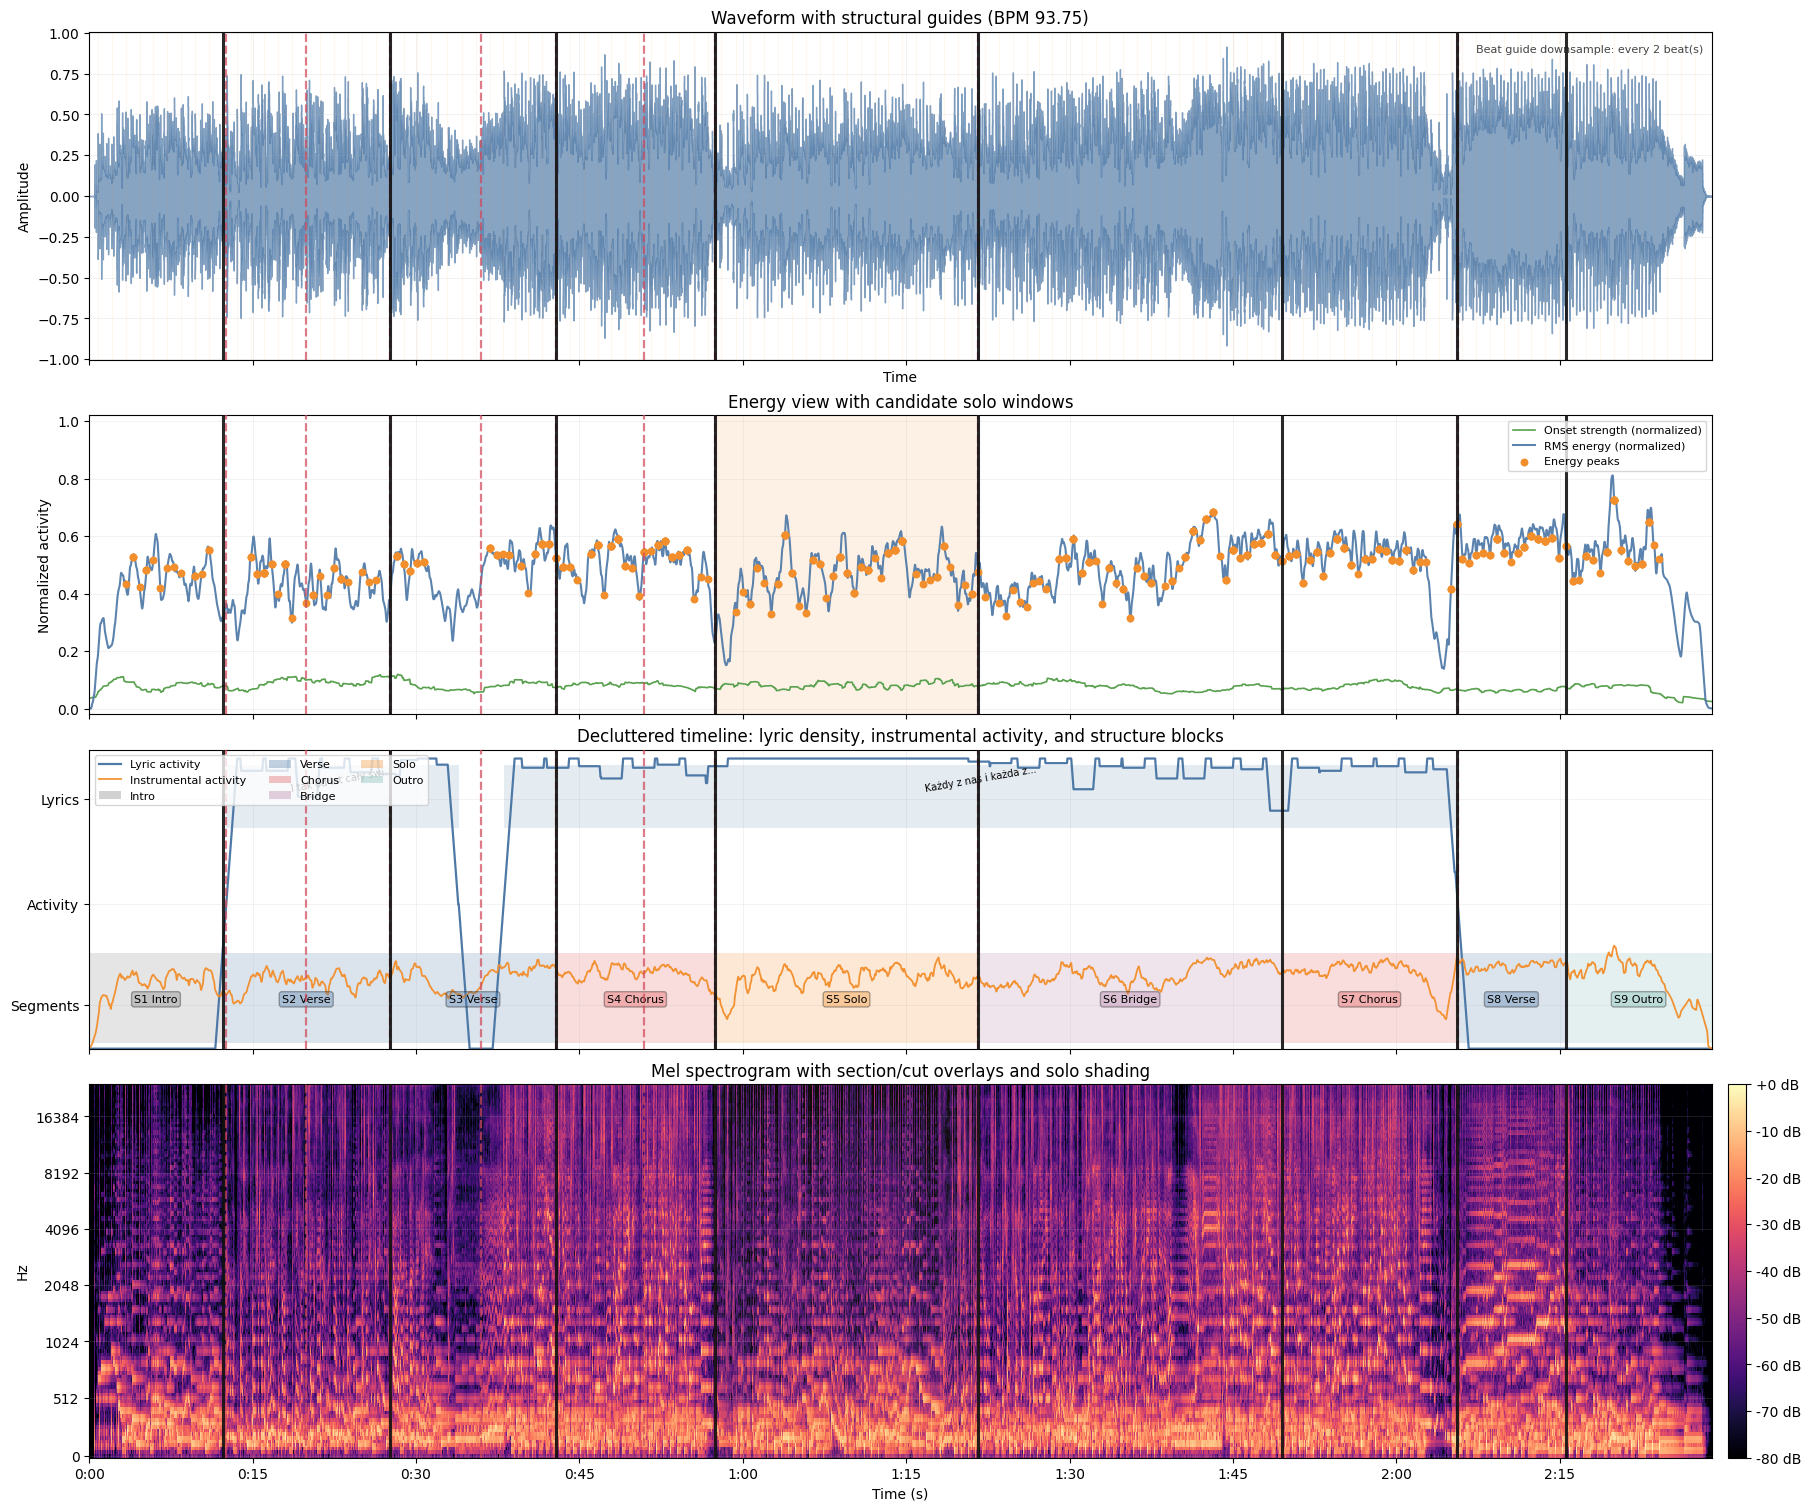

In [14]:
from matplotlib.patches import Patch

STRUCTURE_COLORS = {
    'Intro': '#7f7f7f',
    'Verse': '#4e79a7',
    'Chorus': '#e15759',
    'Bridge': '#b07aa1',
    'Solo': '#f28e2b',
    'Outro': '#76b7b2',
    'Unknown': '#bab0ab',
}


def normalize_series(values: np.ndarray) -> np.ndarray:
    if values.size == 0:
        return values
    min_value = float(np.min(values))
    max_value = float(np.max(values))
    if max_value - min_value <= 1e-9:
        return np.zeros_like(values, dtype=float)
    return (values - min_value) / (max_value - min_value)


def draw_guides(ax: plt.Axes, boundaries: np.ndarray, cuts: list[float]) -> None:
    for boundary_time in boundaries[1:-1]:
        ax.axvline(boundary_time, color='#d1495b', linestyle='--', linewidth=1.6, alpha=0.72, zorder=4)
    for cut_time in cuts[1:-1]:
        ax.axvline(cut_time, color='#111111', linewidth=2.2, alpha=0.90, zorder=5)


duration = float(analysis['duration'])
onset_norm = normalize_series(onset_values.astype(float))
rms_norm = normalize_series(rms_values.astype(float))
onset_on_rms = np.interp(rms_times, onset_times, onset_norm, left=0.0, right=0.0)

frame_duration = float(np.median(np.diff(rms_times))) if len(rms_times) > 1 else 0.05
activity_window = max(9, int(round(2.0 / max(frame_duration, 1e-3))))
if activity_window % 2 == 0:
    activity_window += 1

onset_display = np.clip(moving_average(onset_norm, max(7, activity_window // 4)), 0.0, 1.0)
rms_display = np.clip(moving_average(rms_norm, max(7, activity_window // 4)), 0.0, 1.0)

lyric_activity = np.zeros_like(rms_times, dtype=float)
for cue in cues:
    cue_start = float(cue.get('start', 0.0))
    cue_end = cue_start + max(0.2, float(cue.get('duration', 0.0)))
    lyric_activity[(rms_times >= cue_start) & (rms_times <= cue_end)] = 1.0
lyric_activity = np.clip(moving_average(lyric_activity, activity_window), 0.0, 1.0)
instrumental_activity = np.clip(0.58 * onset_on_rms + 0.42 * rms_norm, 0.0, 1.0)
instrumental_activity = np.clip(moving_average(instrumental_activity, max(7, activity_window // 2)), 0.0, 1.0)

cue_blocks: list[dict[str, object]] = []
for cue in sorted(cues, key=lambda item: float(item.get('start', 0.0))):
    cue_start = float(cue.get('start', 0.0))
    cue_end = cue_start + max(0.2, float(cue.get('duration', 0.0)))
    text = str(cue.get('text', '')).strip()

    if not cue_blocks or cue_start - float(cue_blocks[-1]['end']) > 0.4:
        cue_blocks.append({'start': cue_start, 'end': cue_end, 'texts': [text] if text else []})
        continue

    cue_blocks[-1]['end'] = max(float(cue_blocks[-1]['end']), cue_end)
    if text and len(cue_blocks[-1]['texts']) < 2:
        cue_blocks[-1]['texts'].append(text)

fig, axes = plt.subplots(
    4,
    1,
    figsize=(18, 15),
    sharex=True,
    constrained_layout=True,
    gridspec_kw={'height_ratios': [1.1, 1.0, 1.0, 1.25]},
)

# Panel 1: waveform and cleaner time guides.
librosa.display.waveshow(audio, sr=sample_rate, ax=axes[0], alpha=0.68, color='#4e79a7')
beat_step = max(1, int(np.ceil(len(beat_grid) / 120)))
for beat_time in beat_grid[::beat_step]:
    axes[0].axvline(beat_time, color='#f28e2b', alpha=0.07, linewidth=0.8)
draw_guides(axes[0], section_boundaries, cut_boundaries)
axes[0].set_title(f"Waveform with structural guides (BPM {analysis['bpm']})")
axes[0].set_ylabel('Amplitude')
axes[0].text(
    0.995,
    0.96,
    f'Beat guide downsample: every {beat_step} beat(s)',
    transform=axes[0].transAxes,
    ha='right',
    va='top',
    fontsize=8,
    color='#444444',
)

# Panel 2: normalized energy signals and solo highlights.
axes[1].plot(onset_times, onset_display, color='#59a14f', linewidth=1.2, label='Onset strength (normalized)')
axes[1].plot(rms_times, rms_display, color='#4e79a7', linewidth=1.5, alpha=0.92, label='RMS energy (normalized)')
if energy_peaks.size:
    peak_values = np.interp(energy_peaks, rms_times, rms_display)
    axes[1].scatter(energy_peaks, peak_values, color='#f28e2b', s=22, zorder=3, label='Energy peaks')

for row in segments:
    if str(row.get('structure_type', 'Unknown')) == 'Solo':
        axes[1].axvspan(float(row['start']), float(row['end']), color='#f28e2b', alpha=0.12)

draw_guides(axes[1], section_boundaries, cut_boundaries)
axes[1].set_title('Energy view with candidate solo windows')
axes[1].set_ylabel('Normalized activity')
axes[1].set_ylim(-0.02, 1.02)
axes[1].legend(loc='upper right', fontsize=8)

# Panel 3: decluttered timeline lanes (lyrics + activity + structure).
axes[2].set_title('Decluttered timeline: lyric density, instrumental activity, and structure blocks')
axes[2].set_ylim(0.0, 1.03)
axes[2].set_yticks([0.15, 0.50, 0.86])
axes[2].set_yticklabels(['Segments', 'Activity', 'Lyrics'])

axes[2].plot(rms_times, lyric_activity, color='#4e79a7', linewidth=1.6, label='Lyric activity')
axes[2].plot(rms_times, instrumental_activity, color='#f28e2b', linewidth=1.3, alpha=0.95, label='Instrumental activity')

for block in cue_blocks:
    block_start = float(block['start'])
    block_end = float(block['end'])
    axes[2].axvspan(block_start, block_end, ymin=0.74, ymax=0.95, color='#4e79a7', alpha=0.15, linewidth=0.0)

label_gap = max(9.0, duration / 10.0)
last_labeled_time = -1e9
for block in cue_blocks:
    block_start = float(block['start'])
    block_end = float(block['end'])
    if block_start - last_labeled_time < label_gap:
        continue

    block_texts = [text for text in block['texts'] if str(text).strip()]
    if not block_texts:
        continue

    label = ' / '.join(str(text) for text in block_texts)
    if len(label) > 24:
        label = label[:21] + '...'

    axes[2].text(
        (block_start + block_end) / 2.0,
        0.98,
        label,
        ha='center',
        va='top',
        fontsize=7,
        rotation=10,
        clip_on=True,
    )
    last_labeled_time = block_start

segment_label_min_duration = max(6.0, duration / 16.0)
for row in segments:
    start = float(row['start'])
    end = float(row['end'])
    center = (start + end) / 2.0
    structure_type = str(row.get('structure_type', 'Unknown'))
    segment_color = STRUCTURE_COLORS.get(structure_type, STRUCTURE_COLORS['Unknown'])

    axes[2].axvspan(start, end, ymin=0.02, ymax=0.32, color=segment_color, alpha=0.20, linewidth=0.0)

    show_label = (end - start) >= segment_label_min_duration or int(row['segment']) in {1, len(segments)}
    if show_label:
        axes[2].text(
            center,
            0.17,
            f"S{int(row['segment'])} {structure_type}",
            ha='center',
            va='center',
            fontsize=8,
            bbox=dict(boxstyle='round,pad=0.24', facecolor=segment_color, edgecolor='#111111', alpha=0.35),
        )

draw_guides(axes[2], section_boundaries, cut_boundaries)

structure_order = ['Intro', 'Verse', 'Chorus', 'Bridge', 'Solo', 'Outro', 'Unknown']
present_structures = [
    name
    for name in structure_order
    if any(str(item.get('structure_type', 'Unknown')) == name for item in segments)
]
structure_handles = [
    Patch(facecolor=STRUCTURE_COLORS[name], edgecolor='none', alpha=0.35, label=name)
    for name in present_structures
]
activity_handles, activity_labels = axes[2].get_legend_handles_labels()
all_handles = activity_handles + structure_handles
all_labels = activity_labels + [handle.get_label() for handle in structure_handles]
if all_handles:
    axes[2].legend(all_handles, all_labels, loc='upper left', fontsize=8, ncol=3, frameon=True)

# Panel 4: spectrogram with cleaner overlays.
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    n_fft=2048,
    n_mels=128,
    fmax=min(8000, sample_rate // 2),
)
mel_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(
    mel_db,
    sr=sample_rate,
    hop_length=HOP_LENGTH,
    x_axis='time',
    y_axis='mel',
    ax=axes[3],
    cmap='magma',
)
for row in segments:
    if str(row.get('structure_type', 'Unknown')) == 'Solo':
        axes[3].axvspan(float(row['start']), float(row['end']), color='#f28e2b', alpha=0.07)

draw_guides(axes[3], section_boundaries, cut_boundaries)
axes[3].set_title('Mel spectrogram with section/cut overlays and solo shading')
axes[3].set_xlabel('Time (s)')
fig.colorbar(img, ax=axes[3], format='%+2.0f dB', pad=0.01)

for ax in axes:
    ax.set_xlim(0.0, duration)
    ax.grid(alpha=0.18, linewidth=0.6)

plt.show()